# Opening the published GEFS Icechunk store (source.coop)

The NOAA GEFS ensemble GIK store is published on **source.coop** as a virtual
Icechunk repo. Its metadata (repo pointer + snapshots + manifests + transactions)
lives on source.coop; the actual data chunks are **virtual references** into the
public `s3://noaa-gefs-pds/` GRIB archive on AWS. A reader therefore needs only:

- **anonymous** GET/LIST on source.coop (the store metadata), and
- **anonymous** GET on `noaa-gefs-pds` (the GRIB bytes the virtual chunks point at).

| | value |
|---|---|
| Endpoint | `https://data.source.coop` |
| Bucket | `e4drr-project` |
| Prefix | `forecasts/noaa_gefs_aws_s3_icechunk_vd` |
| Group | `0p25/00z`  &larr; **arrays are here, not at the root** |
| Virtual chunk source | `s3://noaa-gefs-pds/` (anonymous) |
| Chunk codec | `gribberish` (Zarr v3) |

See the [ECMWF companion notebook](https://gist.github.com/nishadhka/3917c3d1b5391bb97c65fd98b06f6ca7) for the multi-era IFS store.

## Dependencies

```
icechunk>=2.1  zarr>=3.2  xarray>=2025.1  gribberish>=1.4  s3fs  numpy  matplotlib
```

No credentials of any kind are required: this notebook reads the store metadata
anonymously from source.coop and the GRIB bytes anonymously from AWS.


In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import icechunk
import xarray as xr
import gribberish.zarr  # noqa: F401 -- registers the "gribberish" Zarr v3 codec

print("icechunk", icechunk.__version__)
print("xarray  ", xr.__version__)

icechunk 2.1.1
xarray   2026.7.0


## Open the store

Three things in this cell are load-bearing, and each is explained in **Gotchas** at
the bottom:

1. `force_path_style=True` and `from_env=False` on the storage,
2. manifest preload turned **off** (source.coop returns sporadic HTTP 500s), and
3. `decode_timedelta=True` on `open_zarr` -- `step` is a timedelta and xarray now
   wants that stated explicitly.

In [2]:
ENDPOINT = "https://data.source.coop"
BUCKET = "e4drr-project"
PREFIX = "forecasts/noaa_gefs_aws_s3_icechunk_vd"
GROUP = "0p25/00z"                          # arrays live here, not at the root
CONTAINER = "s3://noaa-gefs-pds/"           # virtual chunks (public AWS, anon)

t0 = time.time()

storage = icechunk.s3_storage(
    bucket=BUCKET,
    prefix=PREFIX,
    endpoint_url=ENDPOINT,
    region="us-east-1",
    anonymous=True,         # public read of the store metadata
    from_env=False,         # ignore any AWS_* env vars
    force_path_style=True,  # source.coop needs path-style addressing
)

# authorize anonymous byte-range reads of the virtual chunks on AWS
auth = icechunk.containers_credentials(
    {CONTAINER: icechunk.s3_anonymous_credentials()})

# Disable eager manifest preload -- see "source.coop sporadic 500s" in Gotchas.
cfg = icechunk.RepositoryConfig.default()
cfg.manifest = icechunk.ManifestConfig(
    preload=icechunk.ManifestPreloadConfig(max_total_refs=0, max_arrays_to_scan=0))

repo = icechunk.Repository.open(
    storage, config=cfg, authorize_virtual_chunk_access=auth)

ds = xr.open_zarr(
    repo.readonly_session("main").store,
    group=GROUP,
    consolidated=False,
    zarr_format=3,
    decode_timedelta=True,  # `step` carries timedelta-like units -- say so explicitly
)

print(f"opened in {time.time() - t0:.1f}s")

opened in 135.9s


### `decode_timedelta=True` is what silences the FutureWarning

`step` is stored with a timedelta-like `units` attribute but no `dtype` attribute.
Historically xarray decoded that into `timedelta64[ns]` by guessing from `units`;
that guess is being removed, so xarray warns unless you state your intent:

```
FutureWarning: In a future version, xarray will not decode the variable 'step'
into a timedelta64 dtype based on the presence of a timedelta-like 'units'
attribute by default...
```

Passing `decode_timedelta=True` keeps today's behaviour (`step` stays a real
`timedelta64[ns]`, so `ds.step` prints as `0 days`, `0 days 03:00:00`, ...) and is
forward-compatible. Passing `False` would instead give you raw integer nanoseconds.
`True` is what you want here.

In [3]:
print(ds)

<xarray.Dataset> Size: 697TB
Dimensions:            (time: 2031, number: 30, step: 81, latitude: 721,
                        longitude: 1440)
Coordinates:
  * time               (time) datetime64[ns] 16kB 2020-09-23 ... 2026-04-15
  * number             (number) int16 60B 1 2 3 4 5 6 7 ... 24 25 26 27 28 29 30
  * step               (step) timedelta64[ns] 648B 00:00:00 ... 10 days 00:00:00
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
Data variables: (12/34)
    avg_slhtf          (time, number, step, latitude, longitude) float32 20TB ...
    avg_ishf           (time, number, step, latitude, longitude) float32 20TB ...
    cin                (time, number, step, latitude, longitude) float32 20TB ...
    crain              (time, number, step, latitude, longitude) float32 20TB ...
    cpofp              (time, number, step, latitude, longitude) float32 20TB ...
    csnow       

## Size: three numbers, don't conflate them

| measure | size | meaning |
|---|---|---|
| store objects on source.coop | 5.4 GB | what is actually hosted |
| **referenced GRIB** (packed) | ~92 TB | bytes pulled if you read the whole store once |
| dense float32 (`ds.nbytes`) | 697 TB | xarray's "Size: 697TB" -- **misleading** |

`ds.nbytes` assumes every `time x number x step x lat x lon` cell exists and is
stored uncompressed. Real GRIB2 is packed, and many cells have no message at all
(accumulated vars at `step=0`). Nothing is materialized on open -- you only fetch
the byte ranges you actually index.

In [4]:
print("dims      :", dict(ds.sizes))
print("data vars :", len(ds.data_vars))
print("           ", ", ".join(sorted(ds.data_vars)))
print()
print(f"time      : {ds.sizes['time']} runs, "
      f"{np.datetime_as_string(ds.time.values.min(), unit='D')} .. "
      f"{np.datetime_as_string(ds.time.values.max(), unit='D')} (00z)")
print(f"step      : {ds.sizes['step']} steps, {ds.step.values[0].astype('timedelta64[h]')} .. "
      f"{ds.step.values[-1].astype('timedelta64[h]')}")
print(f"number    : {ds.sizes['number']} members (gep01..gep{ds.sizes['number']:02d})")
print()
print(f"dense float32 (ds.nbytes)    : {ds.nbytes / 1e12:.0f} TB  ({ds.nbytes:,} bytes)")
print(f"referenced GRIB (packed)     : ~92 TB")
print(f"store objects on source.coop : ~5.4 GB")

dims      : {'time': 2031, 'number': 30, 'step': 81, 'latitude': 721, 'longitude': 1440}
data vars : 34
            avg_ishf, avg_slhtf, cape, cfrzr, cicep, cin, cpofp, crain, csnow, d2m, gh, gust, mslet, orog, prmsl, pwat, r2, sde, sdlwrf, sdswrf, sdwe, sithick, sp, sulwrf_nominalTop, sulwrf_surface, suswrf, t2m, tcc, tmax, tmin, tp, u10, v10, vis

time      : 2031 runs, 2020-09-23 .. 2026-04-15 (00z)
step      : 81 steps, 0 hours .. 240 hours
number    : 30 members (gep01..gep30)

dense float32 (ds.nbytes)    : 697 TB  (696,871,754,645,444 bytes)
referenced GRIB (packed)     : ~92 TB
store objects on source.coop : ~5.4 GB


## Read one field

This resolves a virtual chunk: icechunk maps the `(time, number, step)` index to a
byte range in a GRIB file on `noaa-gefs-pds`, fetches just those bytes, and
gribberish decodes the message.

In [5]:
ti = int(np.argmax(ds["time"].values))          # newest run
newest = np.datetime_as_string(ds["time"].values[ti], unit="D")

t1 = time.time()
t2m = ds["t2m"].isel(time=ti, number=0, step=0)  # (latitude, longitude), Kelvin
t2m = t2m.compute()
print(f"t2m @ {newest}, member gep01, f000")
print(f"  shape {t2m.shape} decoded in {time.time() - t1:.2f}s")
print(f"  finite fraction {np.isfinite(t2m.values).mean():.3f}")
print(f"  min/mean/max = {float(t2m.min()):.4g} / {float(t2m.mean()):.4g} / "
      f"{float(t2m.max()):.4g} K")

t2m @ 2026-04-15, member gep01, f000
  shape (721, 1440) decoded in 3.88s
  finite fraction 1.000
  min/mean/max = 212.4 / 278.1 / 311 K


In [6]:
def plot_field(field, title, cbar_label, cmap="viridis", levels=21):
    """Filled contour of a (latitude, longitude) DataArray on a plain lat/lon grid."""
    fig, ax = plt.subplots(figsize=(12, 5.5))
    m = ax.contourf(field["longitude"], field["latitude"], field.values,
                    levels=levels, cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("longitude (deg east)")
    ax.set_ylabel("latitude (deg north)")
    ax.set_aspect("equal")
    fig.colorbar(m, ax=ax, label=cbar_label, shrink=0.85)
    plt.tight_layout()
    plt.show()

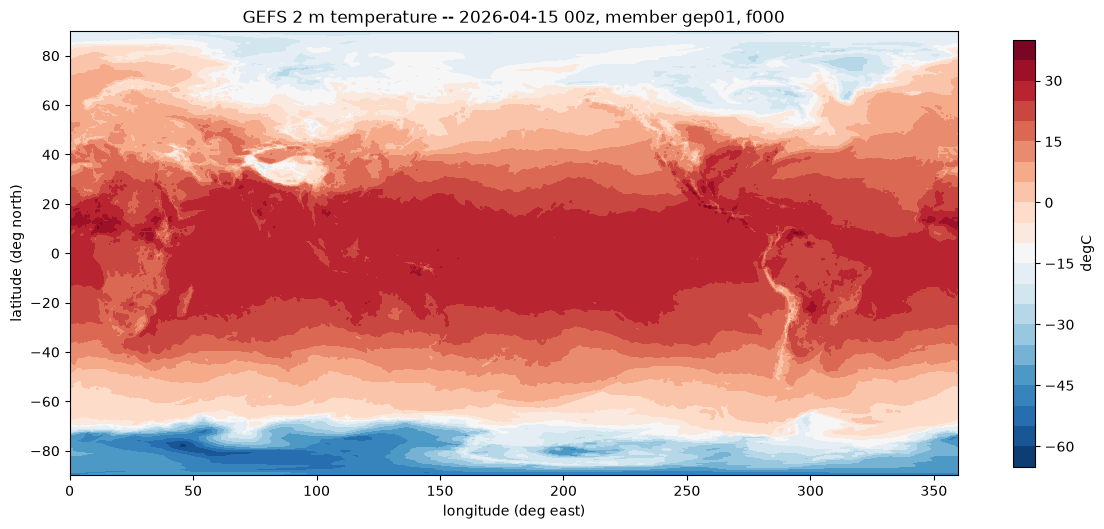

In [7]:
plot_field(t2m - 273.15,
           f"GEFS 2 m temperature -- {newest} 00z, member gep01, f000",
           "degC", cmap="RdBu_r")

## The height layer: this store doesn't have one

GEFS's published `pgrb2s` 0.25 deg product is **surface / single-level only**. The
store has **no `isobaricInhPa` dimension at all**, so there is no 500 hPa chart to
draw from it -- every variable, `gh` included, is 5-D
`(time, number, step, latitude, longitude)`.

And `gh` here is **not** geopotential height on a pressure level. The GIK builder
selects the GRIB `hgt` messages at `typeOfLevel='cloudCeiling'` (see
`gefs/lithops-cr-gik-gefs/run_lithops_gefs.py`), so `gh` in this store is **cloud
ceiling height** in metres. The decoded values below confirm it: a 500 hPa
geopotential height field would sit in a narrow ~4900-5900 m band, whereas this field
spans ~0-20000 m, where **20000 m is GEFS's "unlimited ceiling" fill** covering most
clear-sky grid points (which is what drags the mean up to ~15700 m).

**If you want a real pressure-level height layer -- 500 hPa geopotential height, on a
14-level vertical axis -- use the ECMWF store instead**; see the [ECMWF notebook](https://gist.github.com/nishadhka/3917c3d1b5391bb97c65fd98b06f6ca7).
The cells below show what this store actually gives you.

In [8]:
print("vertical coord present? ", "isobaricInhPa" in ds.dims)
print("gh dims               : ", ds["gh"].dims)
print("=> no pressure-level axis: gh is a single-level (cloudCeiling) field")

vertical coord present?  False
gh dims               :  ('time', 'number', 'step', 'latitude', 'longitude')
=> no pressure-level axis: gh is a single-level (cloudCeiling) field


In [9]:
t1 = time.time()
gh = ds["gh"].isel(time=ti, number=0, step=0).compute()   # cloud ceiling, metres
print(f"gh (cloud ceiling) decoded in {time.time() - t1:.2f}s -- shape {gh.shape}")
print(f"  min/mean/max = {float(gh.min()):.0f} / {float(gh.mean()):.0f} / "
      f"{float(gh.max()):.0f} m")
print(f"  fraction at the 20000 m 'unlimited ceiling' fill: "
      f"{float((gh >= 20000).mean()):.3f}")
print()
print("  a 500 hPa geopotential height field would be ~4900-5900 m everywhere;")
print("  this is not that -- it is cloud ceiling.")

gh (cloud ceiling) decoded in 2.61s -- shape (721, 1440)
  min/mean/max = 7 / 15741 / 20000 m
  fraction at the 20000 m 'unlimited ceiling' fill: 0.696

  a 500 hPa geopotential height field would be ~4900-5900 m everywhere;
  this is not that -- it is cloud ceiling.


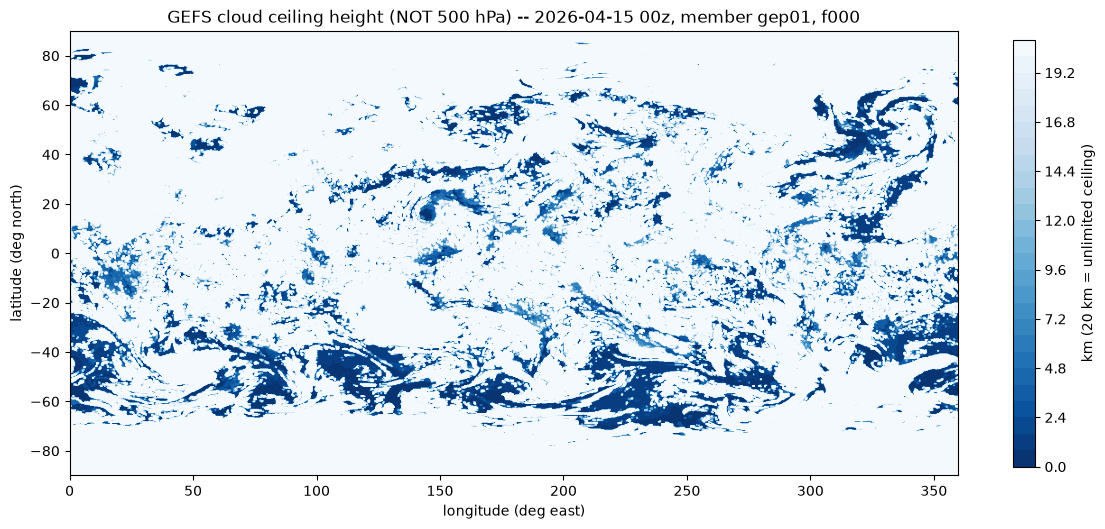

In [10]:
plot_field(gh / 1000.0,
           f"GEFS cloud ceiling height (NOT 500 hPa) -- {newest} 00z, member gep01, f000",
           "km (20 km = unlimited ceiling)", cmap="Blues_r", levels=25)

## Gotchas

- **Arrays are under group `0p25/00z`.** Opening the root group returns an empty
  dataset (no data vars) -- this is expected, not a broken store.
- **Pass `decode_timedelta=True`.** Otherwise xarray raises a `FutureWarning` about
  decoding `step` from its `units` attribute. See the note above.
- **Disable eager manifest preload (source.coop sporadic 500s).** source.coop returns
  transient `HTTP 500` ("service error") on a small % of GETs under concurrency. This
  is source.coop, *not* AWS S3 (manifests live on source.coop; the GRIB byte-range
  reads to `noaa-gefs-pds` are never even reached at open time), and it is *not* a
  rate limit (128-way concurrent GET bursts succeed). But icechunk's default open
  **prefetches thousands of manifests in parallel**, so at a few-% error rate at
  least one *critical* fetch tends to draw a 500 and the whole open raises
  `IcechunkError: object store error service error`. The
  `ManifestPreloadConfig(max_total_refs=0, max_arrays_to_scan=0)` above turns preload
  off: manifests then load lazily on demand (with retry). Open is slower (~60 s vs a
  few s) but robust and silent. Retrying the default open a few times also usually
  succeeds, since the failure is probabilistic.
- **`gribberish.zarr` must be imported** before reading any chunk, or the decode fails
  with an unknown-codec error. The import registers the Zarr v3 codec.
- **`force_path_style=True`** is required for source.coop; without it the client builds
  a virtual-host URL that source.coop does not serve.
- **`from_env=False`** -- pass it so stray `AWS_*` env vars (e.g. a leftover
  `source .env` for publishing) don't turn the anonymous read into a signed one.
- **Accumulated vars have no f000 message.** `tp`/`tmax`/`tmin` etc. are all-NaN at
  `step=0` by construction; use `step>=1`. Instant vars (`t2m`, `u10`, ...) decode at
  `step=0`.
- **`time` may not be globally sorted** if the store was gap-filled out of order; call
  `ds.sortby("time")` if you need monotonic time.